In [2]:
import qbiome
from qbiome.data_formatter import DataFormatter
from qbiome.quantizer import Quantizer
from qbiome.qnet_orchestrator import QnetOrchestrator
from qbiome.forecaster import Forecaster
from qbiome.hypothesis import Hypothesis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")
from qbiome.qutil import qsmooth

In [4]:
# File path to your merged CSV file
file_path = "example_data/Time_Series_Sewage_merged_with_weeks.csv"  # update with actual path if needed

# Read the CSV into a DataFrame
merged_df = pd.read_csv(file_path)

# Preview the first few rows
print(merged_df.head())

   sample_id     Site          taxa_id  rel_abundance      COLLECTION_DATE  \
0  1014216_1  Bologna       Acidovorax       0.276368  2020-03-12 00:00:00   
1  1014216_1  Bologna    Acinetobacter       0.031886  2020-03-12 00:00:00   
2  1014216_1  Bologna        Aeromonas       0.007573  2020-03-12 00:00:00   
3  1014216_1  Bologna    Aliarcobacter       0.005577  2020-03-12 00:00:00   
4  1014216_1  Bologna  Aquabacterium_A       0.000851  2020-03-12 00:00:00   

                               COMPLETE_NAME COUNTRY     CITY  LATITUDE  \
0  DTU_2022_1014216_1_MG_IT_BO_200312_GSL_34   Italy  Bologna   44.4949   
1  DTU_2022_1014216_1_MG_IT_BO_200312_GSL_34   Italy  Bologna   44.4949   
2  DTU_2022_1014216_1_MG_IT_BO_200312_GSL_34   Italy  Bologna   44.4949   
3  DTU_2022_1014216_1_MG_IT_BO_200312_GSL_34   Italy  Bologna   44.4949   
4  DTU_2022_1014216_1_MG_IT_BO_200312_GSL_34   Italy  Bologna   44.4949   

   LONGITUDE        PLANT  relative_week  
0    11.3426  Gruppo HERA            

In [5]:
# Select the desired columns
data = merged_df[['sample_id', 'Site', 'taxa_id', 'rel_abundance', 'relative_week']].copy()

# Rename the columns
data.rename(columns={
    'Site': 'subject_id',
    'taxa_id': 'variable',
    'rel_abundance': 'value',
    'relative_week': 'week'
}, inplace=True)

# Preview the result
print(data.head())

   sample_id subject_id         variable     value  week
0  1014216_1    Bologna       Acidovorax  0.276368    58
1  1014216_1    Bologna    Acinetobacter  0.031886    58
2  1014216_1    Bologna        Aeromonas  0.007573    58
3  1014216_1    Bologna    Aliarcobacter  0.005577    58
4  1014216_1    Bologna  Aquabacterium_A  0.000851    58


In [6]:
base_tax = "Time_Series_Sewage"

In [7]:
biome=data.variable.values[1]
biome

'Acinetobacter'

In [8]:
quantizer = Quantizer(num_levels=10)
qnet_orchestrator = QnetOrchestrator(quantizer)
quantized = quantizer.quantize_df(data)
features, label_matrix = quantizer.get_qnet_inputs(quantized)

In [7]:
display(features)
display(label_matrix)

Index(['Acidovorax_0', 'Acidovorax_2', 'Acidovorax_8', 'Acidovorax_12',
       'Acidovorax_16', 'Acidovorax_21', 'Acidovorax_25', 'Acidovorax_30',
       'Acidovorax_34', 'Acidovorax_36',
       ...
       'merged_125', 'merged_127', 'merged_130', 'merged_132', 'merged_134',
       'merged_138', 'merged_139', 'merged_140', 'merged_142', 'merged_144'],
      dtype='object', length=4275)

array([['', '', '', ..., '', '', ''],
       ['', '', '', ..., '', '', ''],
       ['E', 'A', '', ..., '', '', ''],
       ...,
       ['', '', 'J', ..., '', '', ''],
       ['', '', '', ..., '', '', ''],
       ['', '', '', ..., 'E', 'E', 'E']], shape=(7, 4275), dtype='<U1')

In [8]:
TAXA = list(data.variable.value_counts().index.values)
TAXA

['Acidovorax',
 'Acinetobacter',
 'Aeromonas',
 'Aliarcobacter',
 'Aquabacterium_A',
 'Bacteroides',
 'Brachymonas',
 'Brevefilum',
 'Brevundimonas',
 'Cloacibacterium',
 'Comamonas',
 'Competibacter_A',
 'Enterobacter',
 'Fermentibacter',
 'Flavobacterium',
 'Giesbergeria',
 'Hydrogenophaga',
 'JAGOYM01',
 'Janthinobacterium',
 'Kaistella',
 'Lactococcus_A',
 'Lenti-01',
 'Microthrix',
 'Moraxella_A',
 'Neisseria',
 'Novosphingobium',
 'Ottowia',
 'Paracoccus',
 'Phocaeicola',
 'Prevotella',
 'Propionivibrio',
 'Pseudomonas_E',
 'Pseudoxanthomonas',
 'Pseudoxanthomonas_A',
 'Psychrobacter',
 'Rubrivivax',
 'Streptococcus',
 'Telluria',
 'Thauera',
 'Thermomonas',
 'Thiothrix',
 'Tolumonas',
 'Trichococcus',
 'UBA1413',
 'merged']

In [9]:
%%time
qnet_orchestrator.train_qnet(
    features, label_matrix, alpha=0.3, min_samples_split=2, out_fname=None
)


CPU times: user 46min 15s, sys: 52.4 s, total: 47min 7s
Wall time: 48min 59s


In [ ]:
%%time
qnet_orchestrator.save_qnet("example_qnet_"+base_tax+".pkl",GZIP=True)

In [10]:
print("hello")

hello


In [11]:
from quasinet.qnet import load_qnet
outdirname = 'trees_'+base_tax
modelpath="example_qnet_"+base_tax+".pkl.gz"
model=load_qnet(modelpath,gz=True)
model.viz_trees(tree_path=outdirname,big_enough_threshold=1,format='png',
                remove_newline=True,remove_dotfile=True)

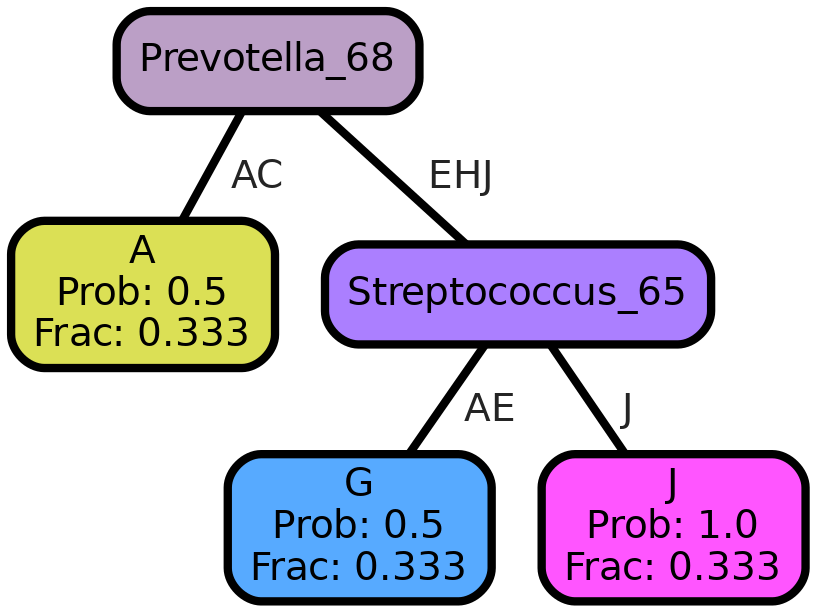

In [12]:
from IPython.display import Image
import glob
Image(filename=glob.glob(outdirname+"/*png")[0])

### Inspect Positive and Negative Regulation (LOMAR coefficients)

In [14]:
qnet_orchestrator.load_qnet("example_qnet_"+base_tax+".pkl.gz",GZIP=True)
hypothesis = Hypothesis(
    quantizer=quantizer,qnet_orchestrator=qnet_orchestrator, detailed_labels=True
)

In [ ]:
hypothesis.causal_constraint = -2
hypothesis.no_self_loops = False

hypothesis.get(time_start=1, time_end=5)
hypothesis.to_dot("hypothesis_1_10.dot")
hypothesis.hypotheses.sort_values("src")

In [ ]:
# if graph-tool is installed
from qbiome.network import Network
Network('hypothesis_1_10.dot',outfile='net.png').get()
# Can also use the external prog
#! python3.7 plotNetwork.py >& /dev/null
from IPython.display import Image
Image(filename='net.png')

### Forecast microbiome evolutionary trajectories

In [9]:
qnet_orchestrator.load_qnet("example_qnet_"+base_tax+".pkl.gz",GZIP=True)

In [14]:
SW = 0
#qnet_orchestrator = QnetOrchestrator(quantizer)
#qnet_orchestrator.load_qnet("example_qnet.pkl.gz",GZIP=True)
forecaster = Forecaster(qnet_orchestrator)
# can specify an end week or default to the max end week in the data
forecasted_ = forecaster.forecast_data(label_matrix, start_week=SW).assign(
    source="forecasted"
)

In [15]:
biome=data.variable.values[2]
biome

'Aeromonas'

In [16]:
DF = forecasted_
SUBJECTS = DF.subject_id.value_counts().index.values
DF

DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

In [17]:
SUBJECTS

array(['Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD',
       'Copenaghen_RL', 'Rome', 'Rotterdam'], dtype=object)

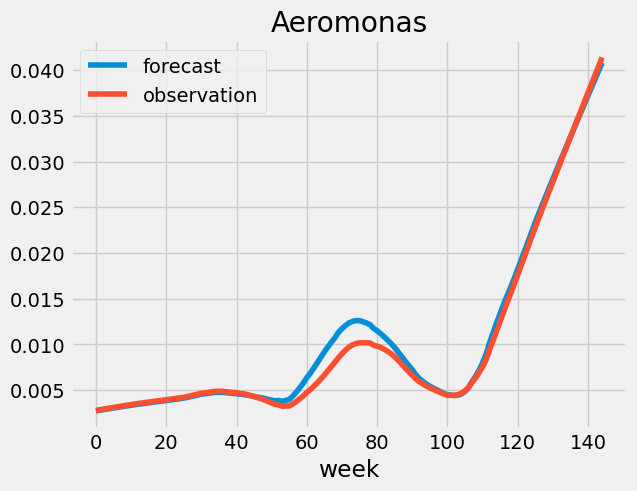

In [18]:
DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

ax = DF_pop_smooth[biome].plot(label="forecast")
DF_data_smooth[biome].plot(ax=ax, label="observation")
ax.set_title(biome)
ax.legend()

In [21]:
DF[DF.subject_id == "Bologna"]

,subject_id,variable,week,value,source
0,Bologna,Acidovorax,0,0.204294,forecasted
7,Bologna,Acidovorax,100,0.035212,forecasted
14,Bologna,Acidovorax,101,0.135700,forecasted
21,Bologna,Acidovorax,102,0.042943,forecasted
28,Bologna,Acidovorax,103,0.100760,forecasted
...,...,...,...,...,...
29890,Bologna,merged,95,0.286542,forecasted
29897,Bologna,merged,96,0.466763,forecasted
29904,Bologna,merged,97,0.207930,forecasted
29911,Bologna,merged,98,0.162671,forecasted


In [23]:
DF[DF.subject_id == "Budapest"]

,subject_id,variable,week,value,source
1,Budapest,Acidovorax,0,0.204294,forecasted
8,Budapest,Acidovorax,100,0.035212,forecasted
15,Budapest,Acidovorax,101,0.135700,forecasted
22,Budapest,Acidovorax,102,0.042943,forecasted
29,Budapest,Acidovorax,103,0.100760,forecasted
...,...,...,...,...,...
29891,Budapest,merged,95,0.286542,forecasted
29898,Budapest,merged,96,0.466763,forecasted
29905,Budapest,merged,97,0.207930,forecasted
29912,Budapest,merged,98,0.162671,forecasted


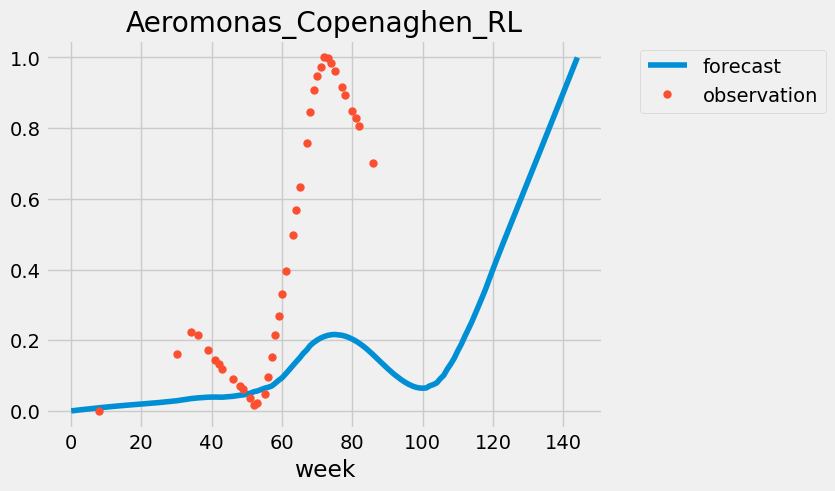

In [19]:
SID = "Copenaghen_RL" #'Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD','Copenaghen_RL', 'Rome', 'Rotterdam']
DF_pop = (
    DF[DF.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_data = (
    data[data.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.6,
)

var = biome
ax = DF_pop_smooth[var].plot(label="forecast")
DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(biome +"_" +SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [1]:
print("hello")

hello
